In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch

import optuna
import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
representation_type = "traditional_word_BOW_element-wise"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "traditional"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"


Connect to databricks for logging results

In [6]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/14 21:10:21 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.1. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/12/14 21:10:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/14 21:10:21 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/14 21:10:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/14 21:10:21 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [7]:
mlflow.sklearn.autolog(disable=True)
mlflow.xgboost.autolog(disable=True)


What are GPU are the experiments run on

In [8]:
!nvidia-smi

Sun Dec 14 21:10:21 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:61:00.0 Off |                    0 |
| N/A   58C    P0             60W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

89

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [13]:
classification_thresholds = [x/1000 for x in range(200, 999)]

TF-IDF parameters for tuning

In [14]:
maximum_features = [20_000, 50_000, 100_000, None]
lowercase = [False, True]
minimum_df = (1e-5, 0.01)
maximum_df = (0.7, 1.0)
binary = [False, True]

# Load dataset

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [00:21<00:00, 530MB/s]


Successfully loaded 273301 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


#### Load validation data

In [18]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:00<00:00, 553MB/s] 


Successfully loaded 2500 items.


In [19]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [20]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 550MB/s] 


Successfully loaded 19999 items.


In [21]:
test_data_df = pd.DataFrame(test_data)

# Extract features functions

Build vectorizer function

In [23]:
def build_bow_vectorizer(max_features, min_df, max_df, lowercase=True, binary=False):
    return CountVectorizer(
        analyzer="word",
        ngram_range=(1, 1),
        max_features=max_features,
        min_df=min_df,
        max_df=max_df,
        lowercase=lowercase,
        binary=binary
    )


Function to fit the vectorizer & return trasnformed training and testing pairs of texts - two tuples with two lists with pairs at the same index

In [24]:
def build_bow_features(vectorizer, train_df, test_df):
    train_texts1 = train_df["pair"].apply(lambda x: x[0])
    train_texts2 = train_df["pair"].apply(lambda x: x[1])
    test_texts1 = test_df["pair"].apply(lambda x: x[0])
    test_texts2 = test_df["pair"].apply(lambda x: x[1])
    
    print("Fitting vectorizer \n")
    vectorizer.fit(pd.concat([train_texts1, train_texts2]))

    print("Transforming texts with vectorizer\n")
    X_train1 = vectorizer.transform(train_texts1)
    X_train2 = vectorizer.transform(train_texts2)
    X_test1 = vectorizer.transform(test_texts1)
    X_test2 = vectorizer.transform(test_texts2)

    X_train = (X_train1, X_train2)
    X_test = (X_test1, X_test2)
    
    return X_train, X_test

Function to return the absolute difference of two lists of transformed text

In [25]:
def compute_element_wise_features(X_pair):
    X_1, X_2 = X_pair
    return X_1 * X_2

# Evaluation functions

Evaluation function

In [26]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Create the confusion matrix

In [27]:
def plot_confusion_matrix(y_true, y_pred, model_id="", labels=[False, True]):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')

    plt.tight_layout()
    return fig

Create histogram of F1 score for different thresholds

In [28]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

# Classifier config setup for optuna studies

In [29]:
class ClassifierConfig: 
    def __init__(self, classifier_object, searched_hyperparameters, fixed_hyperparameters=None):
        self.classifier_object = classifier_object
        self.searched_hyperparameters = searched_hyperparameters or {}
        self.fixed_hyperparameters = fixed_hyperparameters or {}

    def sample_params(self, trial):
        sampled = {
            name: fn(trial)
            for name, fn in self.searched_hyperparameters.items()
        }
        sampled.update(self.fixed_hyperparameters)
        return sampled

# Optuna study function - for classifiers

In [30]:
def objective(trial, config):
    top_f1_trial = -1
    #get the vectorizer hyperparameters
    suggested_max_features = trial.suggest_categorical("max_features", maximum_features)
    suggested_min_df = trial.suggest_float("min_df", minimum_df[0], minimum_df[1])
    suggested_max_df =  trial.suggest_float("max_df", maximum_df[0], maximum_df[1])
    suggested_lowercase = trial.suggest_categorical("lowercase", lowercase)
    suggested_binary = trial.suggest_categorical("binary", binary)
    
    #get the classifier hyperparameters
    classifier_params = config.sample_params(trial)
    
    #set up vectorizer
    vectorizer = build_bow_vectorizer(
        max_features=suggested_max_features,
        min_df=suggested_min_df, 
        max_df=suggested_max_df,
        lowercase=suggested_lowercase,
        binary=suggested_binary
    )
    
    #set up classifier
    classifier = config.classifier_object(**classifier_params)

    #fit the vectorizer and create features of training and test data
    train_data, val_data = build_bow_features(vectorizer, train_data_df, val_data_df)

    #compute the absolute differences between the pairs of features in train and test data
    train_data_diff = compute_element_wise_features(train_data)
    val_data_diff = compute_element_wise_features(val_data)

    #get the labels for train and test data
    y_train = train_data_df["same"].values
    y_test = val_data_df["same"].values
    
    #Fit the classifier
    classifier.fit(train_data_diff, y_train)
    
    #predict the labels for the test data
    y_pred = classifier.predict(val_data_diff)
    
    top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

    print(f"Logging results \n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"max_features: {suggested_max_features}\n")
    print(f"min_df: {suggested_min_df}\n")
    print(f"max_df: {suggested_max_df}\n")
    print(f"lowercase: {suggested_lowercase}\n")
    print(f"binary: {suggested_binary}\n")
    

    trial.set_user_attr(
    "results",
    {
    "metrics": {
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
        },
    "hyperparameters": {
        "max_features": suggested_max_features,
        "min_df": suggested_min_df,
        "max_df": suggested_max_df,
        "lowercase": suggested_lowercase,
        "binary": suggested_binary
        },
    "classifier_hyperparameters": {
            **classifier_params
        },
    }
    )
    print(classifier_params)
    
    return top_f1   

# Evaluate model hyperparameters - Multinomial naïve Bayes

In [31]:
classifier_name = "multinomial_naive_bayes"

In [32]:
multinomial_naive_bayes_config = ClassifierConfig(
    classifier_object=MultinomialNB,
    searched_hyperparameters={
        "alpha": lambda trial: trial.suggest_float("alpha", 1e-3, 1.0, log=True)
    },
    fixed_hyperparameters={}
)

Set up the study

In [33]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-14 21:10:46,782] A new study created in RDB with name: authorship_verification_traditional_word_BOW_absolute_difference_multinomial_naive_bayes


In [34]:
study.optimize(lambda trial: objective(trial, multinomial_naive_bayes_config), n_trials=5)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:10:48,028] Trial 0 finished with value: 49.0 and parameters: {'max_features': 20000, 'min_df': 0.0013204764117791523, 'max_df': 0.8231870037635186, 'lowercase': True, 'binary': True, 'alpha': 0.2998694581582748}. Best is trial 0 with value: 49.0.


Logging results 

Top f1: 49.0

Top accuracy: 58.33

Top precision: 13.21

Top recall: 21.54

Used hyperparameters 

max_features: 20000

min_df: 0.0013204764117791523

max_df: 0.8231870037635186

lowercase: True

binary: True

{'alpha': 0.2998694581582748}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:10:49,279] Trial 1 finished with value: 51.0 and parameters: {'max_features': 20000, 'min_df': 0.002892862959445551, 'max_df': 0.7532360312834007, 'lowercase': False, 'binary': False, 'alpha': 0.002192809553899362}. Best is trial 1 with value: 51.0.


Logging results 

Top f1: 51.0

Top accuracy: 55.0

Top precision: 41.51

Top recall: 47.31

Used hyperparameters 

max_features: 20000

min_df: 0.002892862959445551

max_df: 0.7532360312834007

lowercase: False

binary: False

{'alpha': 0.002192809553899362}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 53.0

Top accuracy: 57.89

Top precision: 41.51

Top recall: 48.35

Used hyperparameters 

max_features: 100000

min_df: 0.006697171564026365

max_df: 0.8786153436530904

lowercase: False

binary: False

{'alpha': 0.09628167661947569}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:10:51,728] Trial 3 finished with value: 51.0 and parameters: {'max_features': 20000, 'min_df': 0.004254907598632131, 'max_df': 0.7170974005273494, 'lowercase': False, 'binary': False, 'alpha': 0.03506321848960625}. Best is trial 2 with value: 53.0.


Logging results 

Top f1: 51.0

Top accuracy: 54.76

Top precision: 43.4

Top recall: 48.42

Used hyperparameters 

max_features: 20000

min_df: 0.004254907598632131

max_df: 0.7170974005273494

lowercase: False

binary: False

{'alpha': 0.03506321848960625}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:10:53,014] Trial 4 finished with value: 52.0 and parameters: {'max_features': 20000, 'min_df': 0.00807046239887032, 'max_df': 0.891968099691348, 'lowercase': True, 'binary': True, 'alpha': 0.23232851525215226}. Best is trial 2 with value: 53.0.


Logging results 

Top f1: 52.0

Top accuracy: 64.71

Top precision: 20.75

Top recall: 31.43

Used hyperparameters 

max_features: 20000

min_df: 0.00807046239887032

max_df: 0.891968099691348

lowercase: True

binary: True

{'alpha': 0.23232851525215226}


Save the study insights

In [35]:
best_trial = study.best_trial
best_params = best_trial.params

date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [36]:
trial_rows = []

for trial in study.trials:
    
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,alpha
0,0,49.0,58.33,13.21,21.54,20000,0.001320,0.823187,True,True,0.299869
1,1,51.0,55.00,41.51,47.31,20000,0.002893,0.753236,False,False,0.002193
2,2,53.0,57.89,41.51,48.35,100000,0.006697,0.878615,False,False,0.096282
3,3,51.0,54.76,43.40,48.42,20000,0.004255,0.717097,False,False,0.035063
4,4,52.0,64.71,20.75,31.43,20000,0.008070,0.891968,True,True,0.232329


In [37]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [38]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Multinomial naïve Bayes

In [39]:
best_params = {}
trial_results = {}

In [40]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [41]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [42]:
trial_results_df = pd.DataFrame(trial_results)

In [43]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]
top_alpha = best_params["alpha"]

In [44]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")
print(f"alpha: {top_alpha}\n")

Used hyperparameters 

max_features: 100000

min_df: 0.006697171564026365

max_df: 0.8786153436530904

lowercase: False

binary: False

alpha: 0.09628167661947569



Reconstruct the best vectorizer

In [45]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [46]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [47]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [48]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [49]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [50]:
classifier = MultinomialNB(alpha=top_alpha)
classifier.fit(train_data_diff, y_train)

MultinomialNB(alpha=0.09628167661947569)

Predict the labels for the test data

In [51]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [52]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 54.0

Top accuracy: 53.12

Top precision: 68.0

Top recall: 59.65



Save the final vectorizer and classifier

In [53]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_multinomial_naive_bayes_best_model.pkl']

Confusion matrix

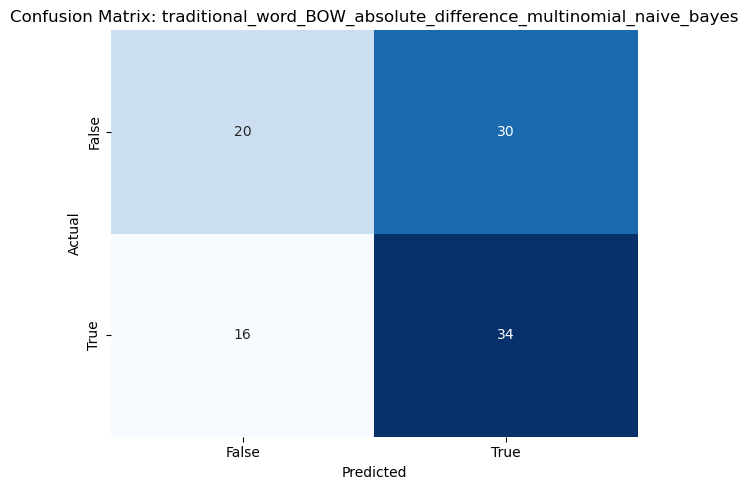

In [54]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [55]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
    mlflow.log_param("alpha", top_alpha)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_MultinomialNB(alpha=0.09628167661947569) at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/1526eca818314ae8922728cc661669a9
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Logistic regression

In [56]:
classifier_name = "logistic_regression"

Resolving the penalty parameter - for both types only certain solvers are possible

In [57]:
logigistic_regression_config = ClassifierConfig(
    classifier_object=LogisticRegression,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "penalty": lambda trial: trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": lambda trial: trial.suggest_categorical("solver", ["liblinear", "saga"]),
    },
    fixed_hyperparameters={
        "max_iter": 5000,
        "n_jobs": -1 #uses all cores
    }
)

Set up the study

In [58]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-14 21:11:01,389] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_logistic_regression' instead of creating a new one.


In [59]:
study.optimize(lambda trial: objective(trial, logigistic_regression_config), n_trials=5)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:09,420] Trial 9 finished with value: 56.0 and parameters: {'max_features': 20000, 'min_df': 0.0090406687754637, 'max_df': 0.9608080984362071, 'lowercase': False, 'binary': False, 'C': 0.30275706642808764, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 4 with value: 57.0.


Logging results 

Top f1: 56.0

Top accuracy: 63.64

Top precision: 39.62

Top recall: 48.84

Used hyperparameters 

max_features: 20000

min_df: 0.0090406687754637

max_df: 0.9608080984362071

lowercase: False

binary: False

{'C': 0.30275706642808764, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
[I 2025-12-14 21:11:10,897] Trial 10 finished with value: 51.0 and parameters: {'max_features': 20000, 'min_df': 0.00570850254451882, 'max_df': 0.7862285603749917, 'lowercase': False, 'binary': True, 'C': 2.8785328919905164, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 4 with value: 57.0.


Logging results 

Top f1: 51.0

Top accuracy: 55.26

Top precision: 39.62

Top recall: 46.15

Used hyperparameters 

max_features: 20000

min_df: 0.00570850254451882

max_df: 0.7862285603749917

lowercase: False

binary: True

{'C': 2.8785328919905164, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 58.0

Top accuracy: 64.1

Top precision: 47.17

Top recall: 54.35

Used hyperparameters 

max_features: 50000

min_df: 0.002691498888098742

max_df: 0.999440757045933

lowercase: True

binary: False

{'C': 0.5245859732313805, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
[I 2025-12-14 21:11:13,658] Trial 12 finished with value: 54.0 and parameters: {'max_features': 50000, 'min_df': 0.0030528995710956772, 'max_df': 0.978095410563197, 'lowercase': True, 'binary': False, 'C': 0.6692818440553585, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 11 with value: 58.0.


Logging results 

Top f1: 54.0

Top accuracy: 60.0

Top precision: 39.62

Top recall: 47.73

Used hyperparameters 

max_features: 50000

min_df: 0.0030528995710956772

max_df: 0.978095410563197

lowercase: True

binary: False

{'C': 0.6692818440553585, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
[I 2025-12-14 21:11:15,069] Trial 13 finished with value: 61.0 and parameters: {'max_features': 50000, 'min_df': 0.0025847756427903427, 'max_df': 0.875590018629494, 'lowercase': True, 'binary': False, 'C': 0.7021268490190026, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 13 with value: 61.0.


Logging results 

Top f1: 61.0

Top accuracy: 68.42

Top precision: 49.06

Top recall: 57.14

Used hyperparameters 

max_features: 50000

min_df: 0.0025847756427903427

max_df: 0.875590018629494

lowercase: True

binary: False

{'C': 0.7021268490190026, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


Save the study insights

In [60]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "max_iter": 5000,
    "n_jobs": -1
})

In [61]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [62]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,C,penalty,solver,max_iter,n_jobs
0,0,55.0,68.18,28.30,40.00,NaN,0.005726,0.869704,False,True,0.191252,l1,saga,5000,-1
1,1,51.0,64.29,16.98,26.87,NaN,0.009298,0.712911,False,True,0.158671,l1,saga,5000,-1
2,2,53.0,57.89,41.51,48.35,20000.0,0.004384,0.808211,False,True,1.856940,l1,saga,5000,-1
3,4,57.0,64.71,41.51,50.57,50000.0,0.002865,0.844246,True,False,0.858906,l1,liblinear,5000,-1
4,5,54.0,66.67,26.42,37.84,NaN,0.009924,0.828792,True,True,0.035249,l2,saga,5000,-1


In [63]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [64]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Logistic regression

In [65]:
best_params = {}
trial_results = {}

In [66]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [67]:
print(best_params)

{'max_features': 50000, 'min_df': 0.0025847756427903427, 'max_df': 0.875590018629494, 'lowercase': True, 'binary': False, 'C': 0.7021268490190026, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


In [68]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [69]:
trial_results_df = pd.DataFrame(trial_results)

In [70]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]
top_c = best_params["C"]
top_penalty = best_params["penalty"]
top_solver = best_params["solver"]
top_max_iter = best_params["max_iter"]
top_n_jobs = best_params["n_jobs"]

In [71]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")
print(f"c: {top_c}\n")
print(f"penalty: {top_penalty}\n")
print(f"solver: {top_solver}\n")
print(f"max_iter: {top_max_iter}\n")
print(f"n_jobs: {top_n_jobs}\n")

Used hyperparameters 

max_features: 50000

min_df: 0.0025847756427903427

max_df: 0.875590018629494

lowercase: True

binary: False

c: 0.7021268490190026

penalty: l2

solver: liblinear

max_iter: 5000

n_jobs: -1



Reconstruct the best vectorizer

In [72]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [73]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [74]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [75]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [76]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [77]:
classifier = LogisticRegression(
    C=top_c,
    penalty=top_penalty,
    solver=top_solver,
    max_iter=top_max_iter,
    n_jobs=top_n_jobs
)
classifier.fit(train_data_diff, y_train)

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(


LogisticRegression(C=0.7021268490190026, max_iter=5000, n_jobs=-1,
                   solver='liblinear')

Predict the labels for the test data

In [78]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [79]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 56.0

Top accuracy: 55.36

Top precision: 62.0

Top recall: 58.49



Save the final vectorizer and classifier

In [80]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_logistic_regression_best_model.pkl']

Confusion matrix

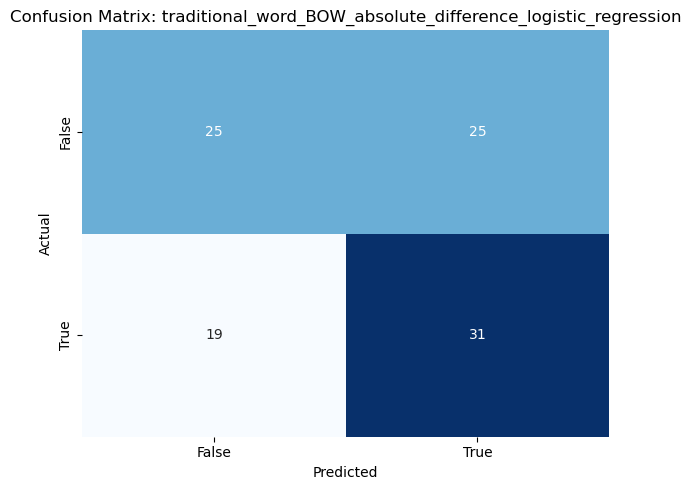

In [81]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [82]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
    mlflow.log_param("C", top_c)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("solver", top_solver)
    mlflow.log_param("max_iter", top_max_iter)
    mlflow.log_param("n_jobs", top_n_jobs)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_logistic_regression at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/72091e954240497f84303a32a9dd9ba2
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Linear SVC

In [83]:
classifier_name = "linear_svc"

In [84]:
linear_svc_config = ClassifierConfig(
    classifier_object=LinearSVC,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "loss": lambda trial: trial.suggest_categorical("loss", ["hinge", "squared_hinge"]),
        "class_weight": lambda trial: trial.suggest_categorical("class_weight", [None, "balanced"]),
    },
    fixed_hyperparameters={
        "penalty": "l2",       # LinearSVC ONLY supports l2
        "dual": True,          # for high-dimensional data (TF-IDF)
        "max_iter": 5000       # ensure convergence
    }
)

Set up the study

In [85]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-14 21:11:23,670] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_linear_svc' instead of creating a new one.


In [86]:
study.optimize(lambda trial: objective(trial, linear_svc_config), n_trials=5)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:25,170] Trial 5 finished with value: 64.0 and parameters: {'max_features': 20000, 'min_df': 0.008080754595894503, 'max_df': 0.90632299436035, 'lowercase': True, 'binary': False, 'C': 0.022052777971436878, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 5 with value: 64.0.


Logging results 

Top f1: 64.0

Top accuracy: 68.89

Top precision: 58.49

Top recall: 63.27

Used hyperparameters 

max_features: 20000

min_df: 0.008080754595894503

max_df: 0.90632299436035

lowercase: True

binary: False

{'C': 0.022052777971436878, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:26,459] Trial 6 finished with value: 60.0 and parameters: {'max_features': 100000, 'min_df': 0.0011796854949435906, 'max_df': 0.8072555277706543, 'lowercase': False, 'binary': False, 'C': 0.018223580649718445, 'loss': 'hinge', 'class_weight': None}. Best is trial 5 with value: 64.0.


Logging results 

Top f1: 60.0

Top accuracy: 67.57

Top precision: 47.17

Top recall: 55.56

Used hyperparameters 

max_features: 100000

min_df: 0.0011796854949435906

max_df: 0.8072555277706543

lowercase: False

binary: False

{'C': 0.018223580649718445, 'loss': 'hinge', 'class_weight': None, 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 56.0

Top accuracy: 66.67

Top precision: 33.96

Top recall: 45.0

Used hyperparameters 

max_features: 20000

min_df: 0.009247128819278815

max_df: 0.7723669034326932

lowercase: True

binary: True

{'C': 0.03398382502473805, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:29,136] Trial 8 finished with value: 59.0 and parameters: {'max_features': 100000, 'min_df': 0.009537665599283646, 'max_df': 0.8407488524102124, 'lowercase': False, 'binary': True, 'C': 1.0284179645957146, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 5 with value: 64.0.


Logging results 

Top f1: 59.0

Top accuracy: 71.43

Top precision: 37.74

Top recall: 49.38

Used hyperparameters 

max_features: 100000

min_df: 0.009537665599283646

max_df: 0.8407488524102124

lowercase: False

binary: True

{'C': 1.0284179645957146, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:30,464] Trial 9 finished with value: 59.0 and parameters: {'max_features': None, 'min_df': 0.0013778948908822382, 'max_df': 0.8578541650209721, 'lowercase': False, 'binary': True, 'C': 0.6694322356982653, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 5 with value: 64.0.


Logging results 

Top f1: 59.0

Top accuracy: 73.08

Top precision: 35.85

Top recall: 48.1

Used hyperparameters 

max_features: None

min_df: 0.0013778948908822382

max_df: 0.8578541650209721

lowercase: False

binary: True

{'C': 0.6694322356982653, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}


Save the study insights

In [87]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "penalty": "l2",       
    "dual": True,          
    "max_iter": 5000
})


In [88]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [89]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,C,loss,class_weight,penalty,dual,max_iter
0,0,56.0,60.98,47.17,53.19,50000.0,0.004713,0.935506,True,False,1.787320,squared_hinge,balanced,l2,True,5000
1,1,61.0,65.22,56.60,60.61,20000.0,0.007910,0.791219,True,False,1.702283,hinge,None,l2,True,5000
2,2,58.0,70.37,35.85,47.50,NaN,0.005255,0.723267,False,True,0.328271,hinge,None,l2,True,5000
3,3,62.0,65.96,58.49,62.00,50000.0,0.007702,0.799680,True,False,2.842693,squared_hinge,balanced,l2,True,5000
4,4,60.0,74.07,37.74,50.00,NaN,0.002402,0.967023,False,True,0.227619,hinge,None,l2,True,5000


In [90]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [91]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Linear SVC

In [92]:
best_params = {}
trial_results = {}

In [93]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [94]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [95]:
trial_results_df = pd.DataFrame(trial_results)

In [96]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_c = best_params["C"]
top_loss = best_params["loss"]
top_class_weight = best_params["class_weight"]
top_penalty = best_params["penalty"]
top_dual = best_params["dual"]
top_max_iter = best_params["max_iter"]

In [97]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"c: {top_c}\n")
print(f"loss: {top_loss}\n")
print(f"class_weight: {top_class_weight}\n")
print(f"penalty: {top_penalty}\n")
print(f"dual: {top_dual}\n")
print(f"max_iter: {top_max_iter}\n")

Used hyperparameters 

max_features: 20000

min_df: 0.008080754595894503

max_df: 0.90632299436035

lowercase: True

binary: False

c: 0.022052777971436878

loss: squared_hinge

class_weight: balanced

penalty: l2

dual: True

max_iter: 5000



Reconstruct the best vectorizer

In [98]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [99]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [100]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [101]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [102]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [103]:
classifier = LinearSVC(
    C=top_c,
    loss=top_loss,
    class_weight=top_class_weight,
    penalty=top_penalty,
    dual=top_dual,
    max_iter=top_max_iter
)

classifier.fit(train_data_diff, y_train)

LinearSVC(C=0.022052777971436878, class_weight='balanced', dual=True,
          max_iter=5000)

Predict the labels for the test data

In [104]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [105]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 57.0

Top accuracy: 56.36

Top precision: 62.0

Top recall: 59.05



Save the final vectorizer and classifier

In [106]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_linear_svc_best_model.pkl']

Confusion matrix

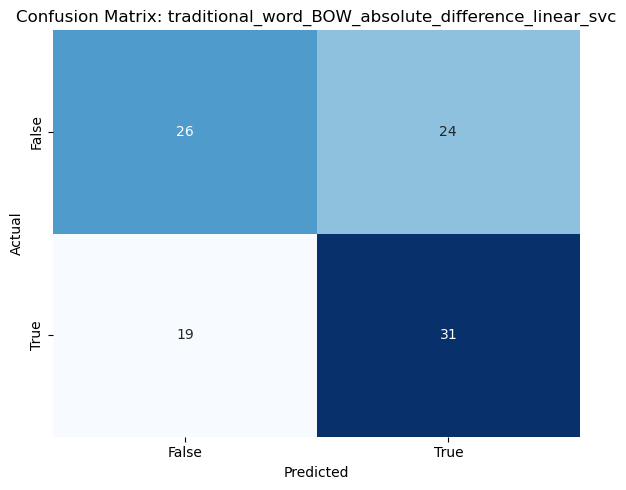

In [107]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [108]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("C", top_c)
    mlflow.log_param("loss", top_loss)
    mlflow.log_param("class_weight", top_class_weight)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("dual", top_dual)
    mlflow.log_param("max_iter", top_max_iter)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_linear_svc at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/e5321028a039476ebde86838b2851d44
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - K-nearest neighbors

In [109]:
classifier_name = "k-nearest_neighbors"

In [110]:
knn_config = ClassifierConfig(
    classifier_object=KNeighborsClassifier,
    searched_hyperparameters={
        "n_neighbors": lambda trial: trial.suggest_int("n_neighbors", 1, 50),
        "weights": lambda trial: trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": lambda trial: trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
    },
    fixed_hyperparameters={
        "algorithm": "auto"
    }
)

Set up the study

In [111]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-14 21:11:40,664] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_k-nearest_neighbors' instead of creating a new one.


In [112]:
study.optimize(lambda trial: objective(trial, knn_config), n_trials=5)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:42,117] Trial 5 finished with value: 63.0 and parameters: {'max_features': None, 'min_df': 0.0032219108026156243, 'max_df': 0.7977441409241907, 'lowercase': False, 'binary': False, 'n_neighbors': 43, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 4 with value: 66.0.


Logging results 

Top f1: 63.0

Top accuracy: 71.05

Top precision: 50.94

Top recall: 59.34

Used hyperparameters 

max_features: None

min_df: 0.0032219108026156243

max_df: 0.7977441409241907

lowercase: False

binary: False

{'n_neighbors': 43, 'weights': 'uniform', 'metric': 'manhattan', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:43,457] Trial 6 finished with value: 54.0 and parameters: {'max_features': 20000, 'min_df': 0.00838683653597473, 'max_df': 0.9455118657127758, 'lowercase': True, 'binary': True, 'n_neighbors': 25, 'weights': 'distance', 'metric': 'euclidean'}. Best is trial 4 with value: 66.0.


Logging results 

Top f1: 54.0

Top accuracy: 53.61

Top precision: 98.11

Top recall: 69.33

Used hyperparameters 

max_features: 20000

min_df: 0.00838683653597473

max_df: 0.9455118657127758

lowercase: True

binary: True

{'n_neighbors': 25, 'weights': 'distance', 'metric': 'euclidean', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 48.0

Top accuracy: 66.67

Top precision: 3.77

Top recall: 7.14

Used hyperparameters 

max_features: 20000

min_df: 0.006727712969916282

max_df: 0.7475419984775833

lowercase: True

binary: True

{'n_neighbors': 3, 'weights': 'distance', 'metric': 'cosine', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:46,116] Trial 8 finished with value: 47.0 and parameters: {'max_features': None, 'min_df': 0.005341201261857743, 'max_df': 0.9508025936155252, 'lowercase': False, 'binary': True, 'n_neighbors': 32, 'weights': 'distance', 'metric': 'cosine'}. Best is trial 4 with value: 66.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: None

min_df: 0.005341201261857743

max_df: 0.9508025936155252

lowercase: False

binary: True

{'n_neighbors': 32, 'weights': 'distance', 'metric': 'cosine', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:47,496] Trial 9 finished with value: 47.0 and parameters: {'max_features': 100000, 'min_df': 0.007704569572115402, 'max_df': 0.9483643118914475, 'lowercase': False, 'binary': True, 'n_neighbors': 9, 'weights': 'uniform', 'metric': 'cosine'}. Best is trial 4 with value: 66.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 100000

min_df: 0.007704569572115402

max_df: 0.9483643118914475

lowercase: False

binary: True

{'n_neighbors': 9, 'weights': 'uniform', 'metric': 'cosine', 'algorithm': 'auto'}


Save the study insights

In [113]:
best_trial = study.best_trial
best_params = best_trial.params

best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "algorithm": "auto"
})

In [114]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [115]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,n_neighbors,weights,metric,algorithm
0,0,51.0,55.00,41.51,47.31,20000.0,0.003271,0.876259,False,False,7,uniform,cosine,auto
1,1,56.0,54.74,98.11,70.27,50000.0,0.005582,0.878622,False,False,2,distance,euclidean,auto
2,2,62.0,59.49,88.68,71.21,NaN,0.005377,0.702201,False,False,2,uniform,euclidean,auto
3,3,60.0,57.65,92.45,71.01,50000.0,0.009356,0.870784,False,True,28,uniform,manhattan,auto
4,4,66.0,72.09,58.49,64.58,50000.0,0.003958,0.845882,True,False,30,distance,manhattan,auto


In [116]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [117]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - K-nearest neighbors

In [118]:
best_params = {}
trial_results = {}

In [119]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [120]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [121]:
trial_results_df = pd.DataFrame(trial_results)

In [122]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_n_neighbors = best_params["n_neighbors"]
top_weights = best_params["weights"]
top_metric = best_params["metric"]
top_algorithm = best_params["algorithm"]

In [123]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"n_neighbors: {top_n_neighbors}\n")
print(f"weights: {top_weights}\n")
print(f"metric: {top_metric}\n")
print(f"algorithm: {top_algorithm}\n")

Used hyperparameters 

max_features: 50000

min_df: 0.00395767320908724

max_df: 0.8458816516910723

lowercase: True

binary: False

n_neighbors: 30

weights: distance

metric: manhattan

algorithm: auto



Reconstruct the best vectorizer

In [124]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [125]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [126]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [127]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [128]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [129]:
classifier = KNeighborsClassifier(
    n_neighbors=top_n_neighbors,
    weights=top_weights,
    metric=top_metric,
    algorithm=top_algorithm
)

classifier.fit(train_data_diff, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=30, weights='distance')

Predict the labels for the test data

In [130]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [131]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 50.0

Top accuracy: 50.0

Top precision: 100.0

Top recall: 66.67



Save the final vectorizer and classifier

In [132]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_k-nearest_neighbors_best_model.pkl']

Confusion matrix

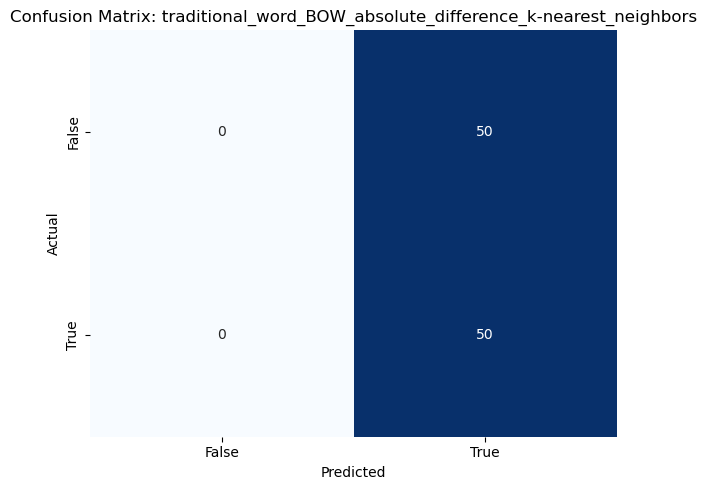

In [133]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [134]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("n_neighbors", top_n_neighbors)
    mlflow.log_param("weights", top_weights)
    mlflow.log_param("metric", top_metric)
    mlflow.log_param("algorithm", top_algorithm)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_k-nearest_neighbors at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/b3b4831a8db9431cb9afbe761ed9fbc5
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Random Forest

In [135]:
classifier_name = "random_forest"

In [136]:
random_forest_config = ClassifierConfig(
    classifier_object=RandomForestClassifier,
    searched_hyperparameters={
        "n_estimators": lambda trial: trial.suggest_int("n_estimators", 100, 600),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": lambda trial: trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": lambda trial: trial.suggest_int("min_samples_leaf", 1, 10)
    },
    fixed_hyperparameters={
        "n_jobs": -1,        # use all cores
        "random_state": 42   # reproducible forests
    }
)

Set up the study

In [137]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-14 21:11:56,014] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_random_forest' instead of creating a new one.


In [138]:
study.optimize(lambda trial: objective(trial, random_forest_config), n_trials=5)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:11:58,602] Trial 11 finished with value: 65.0 and parameters: {'max_features': 20000, 'min_df': 0.0035153455958999258, 'max_df': 0.9996631273110017, 'lowercase': True, 'binary': False, 'n_estimators': 431, 'max_depth': 43, 'min_samples_split': 14, 'min_samples_leaf': 4}. Best is trial 11 with value: 65.0.


Logging results 

Top f1: 65.0

Top accuracy: 84.62

Top precision: 41.51

Top recall: 55.7

Used hyperparameters 

max_features: 20000

min_df: 0.0035153455958999258

max_df: 0.9996631273110017

lowercase: True

binary: False

{'n_estimators': 431, 'max_depth': 43, 'min_samples_split': 14, 'min_samples_leaf': 4, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:12:00,897] Trial 12 finished with value: 64.0 and parameters: {'max_features': 20000, 'min_df': 0.0037941510998535013, 'max_df': 0.9849768607720673, 'lowercase': True, 'binary': False, 'n_estimators': 430, 'max_depth': 42, 'min_samples_split': 15, 'min_samples_leaf': 4}. Best is trial 11 with value: 65.0.


Logging results 

Top f1: 64.0

Top accuracy: 84.0

Top precision: 39.62

Top recall: 53.85

Used hyperparameters 

max_features: 20000

min_df: 0.0037941510998535013

max_df: 0.9849768607720673

lowercase: True

binary: False

{'n_estimators': 430, 'max_depth': 42, 'min_samples_split': 15, 'min_samples_leaf': 4, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 63.0

Top accuracy: 80.77

Top precision: 39.62

Top recall: 53.16

Used hyperparameters 

max_features: 20000

min_df: 0.0037266323361839116

max_df: 0.998489179647834

lowercase: True

binary: False

{'n_estimators': 463, 'max_depth': 40, 'min_samples_split': 15, 'min_samples_leaf': 4, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:12:05,923] Trial 14 finished with value: 54.0 and parameters: {'max_features': 20000, 'min_df': 0.00409840370018442, 'max_df': 0.9518034678037217, 'lowercase': True, 'binary': False, 'n_estimators': 428, 'max_depth': 38, 'min_samples_split': 9, 'min_samples_leaf': 1}. Best is trial 11 with value: 65.0.


Logging results 

Top f1: 54.0

Top accuracy: 68.42

Top precision: 24.53

Top recall: 36.11

Used hyperparameters 

max_features: 20000

min_df: 0.00409840370018442

max_df: 0.9518034678037217

lowercase: True

binary: False

{'n_estimators': 428, 'max_depth': 38, 'min_samples_split': 9, 'min_samples_leaf': 1, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-14 21:12:08,375] Trial 15 finished with value: 59.0 and parameters: {'max_features': 20000, 'min_df': 0.009730518147414918, 'max_df': 0.9513548988590141, 'lowercase': True, 'binary': False, 'n_estimators': 513, 'max_depth': 41, 'min_samples_split': 14, 'min_samples_leaf': 4}. Best is trial 11 with value: 65.0.


Logging results 

Top f1: 59.0

Top accuracy: 73.08

Top precision: 35.85

Top recall: 48.1

Used hyperparameters 

max_features: 20000

min_df: 0.009730518147414918

max_df: 0.9513548988590141

lowercase: True

binary: False

{'n_estimators': 513, 'max_depth': 41, 'min_samples_split': 14, 'min_samples_leaf': 4, 'n_jobs': -1, 'random_state': 42}


Save the study insights

In [139]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "n_jobs": -1,        
    "random_state": 42   
})


In [140]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [141]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,n_estimators,max_depth,min_samples_split,min_samples_leaf,n_jobs,random_state
0,1,57.0,64.71,41.51,50.57,100000.0,0.005991,0.715494,False,True,127,44,20,7,-1,42
1,2,53.0,63.64,26.42,37.33,50000.0,0.007229,0.739899,True,True,184,33,5,8,-1,42
2,3,55.0,75.00,22.64,34.78,50000.0,0.001996,0.729395,False,False,280,48,9,7,-1,42
3,4,59.0,70.00,39.62,50.60,20000.0,0.001483,0.791180,True,False,169,11,13,5,-1,42
4,5,61.0,73.33,41.51,53.01,100000.0,0.007254,0.905720,False,True,227,33,18,6,-1,42


In [142]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [143]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Random forest

In [144]:
best_params = {}
trial_results = {}

In [145]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [146]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [147]:
trial_results_df = pd.DataFrame(trial_results)

In [148]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_n_estimators = best_params["n_estimators"]
top_max_depth = best_params["max_depth"]
top_min_samples_split = best_params["min_samples_split"]
top_min_samples_leaf = best_params["min_samples_leaf"]
top_n_jobs = best_params["n_jobs"]
top_random_state = best_params["random_state"]

In [149]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"n_estimators: {top_n_estimators}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"min_samples_split: {top_min_samples_split}\n")
print(f"min_samples_leaf: {top_min_samples_leaf}\n")
print(f"n_jobs: {top_n_jobs}\n")
print(f"random_state: {top_random_state}\n")

Used hyperparameters 

max_features: 20000

min_df: 0.0035153455958999258

max_df: 0.9996631273110017

lowercase: True

binary: False

n_estimators: 431

max_depth: 43

min_samples_split: 14

min_samples_leaf: 4

n_jobs: -1

random_state: 42



Reconstruct the best vectorizer

In [150]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [151]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [152]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [153]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [154]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [155]:
classifier = RandomForestClassifier(
    n_estimators=top_n_estimators,
    max_depth=top_max_depth,
    min_samples_split=top_min_samples_split,
    min_samples_leaf=top_min_samples_leaf,
    n_jobs=top_n_jobs,
    random_state=top_random_state
)

classifier.fit(train_data_diff, y_train)

RandomForestClassifier(max_depth=43, min_samples_leaf=4, min_samples_split=14,
                       n_estimators=431, n_jobs=-1, random_state=42)

Predict the labels for the test data

In [156]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [157]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 71.0

Top accuracy: 67.8

Top precision: 80.0

Top recall: 73.39



Save the final vectorizer and classifier

In [158]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_random_forest_best_model.pkl']

Confusion matrix

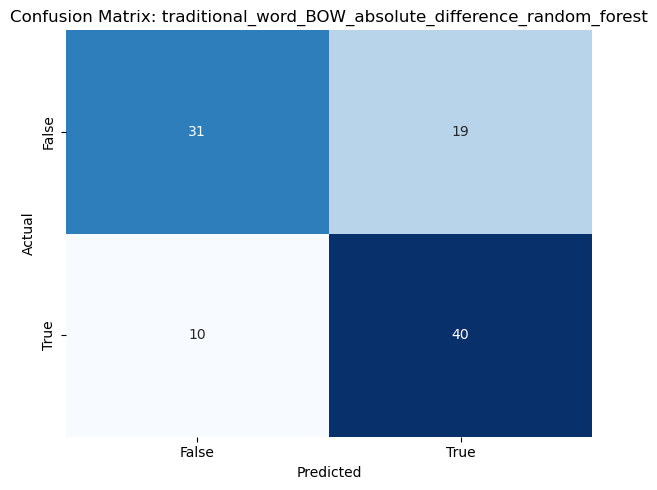

In [159]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [160]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("min_samples_split", top_min_samples_split)
    mlflow.log_param("min_samples_leaf", top_min_samples_leaf)
    mlflow.log_param("n_jobs", top_n_jobs)
    mlflow.log_param("random_state", top_random_state)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_random_forest at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/0f37525bca994deebb1362b0f049084d
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters- XGBoost

In [161]:
classifier_name = "xgboost"

In [162]:
xgboost_config = ClassifierConfig(
    classifier_object=XGBClassifier,
    searched_hyperparameters={
        "eta": lambda trial: trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 3, 12),
        "subsample": lambda trial: trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda trial: trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": lambda trial: trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": lambda trial: trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
    },
    fixed_hyperparameters={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_estimators": 300,     
        "tree_method": "auto", 
        "use_label_encoder": False
    }
)

Set up the study

In [163]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-14 21:12:18,240] Using an existing study with name 'authorship_verification_traditional_word_BOW_absolute_difference_xgboost' instead of creating a new one.


In [164]:
study.optimize(lambda trial: objective(trial, xgboost_config), n_trials=5)

Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:12:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-14 21:12:20,973] Trial 7 finished with value: 51.0 and parameters: {'max_features': 20000, 'min_df': 0.0019065613007780648, 'max_df': 0.8257533935609098, 'lowercase': True, 'binary': True, 'eta': 0.12433990749868537, 'max_depth': 12, 'subsample': 0.8399047311330774, 'colsample_bytree': 0.9725527592806462, 'reg_lambda': 0.004905849195165829, 'reg_alpha': 0.8362921851265093}. Best is trial 3 with value: 65.0.


Logging results 

Top f1: 51.0

Top accuracy: 54.55

Top precision: 45.28

Top recall: 49.48

Used hyperparameters 

max_features: 20000

min_df: 0.0019065613007780648

max_df: 0.8257533935609098

lowercase: True

binary: True

{'eta': 0.12433990749868537, 'max_depth': 12, 'subsample': 0.8399047311330774, 'colsample_bytree': 0.9725527592806462, 'reg_lambda': 0.004905849195165829, 'reg_alpha': 0.8362921851265093, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:12:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-14 21:12:22,696] Trial 8 finished with value: 56.0 and parameters: {'max_features': 100000, 'min_df': 0.005676774504120861, 'max_df': 0.7637183951710143, 'lowercase': True, 'binary': False, 'eta': 0.10737018013376871, 'max_depth': 3, 'subsample': 0.5761400600899623, 'colsample_bytree': 0.5130406384209238, 'reg_lambda': 0.050660613811464666, 'reg_alpha': 0.787815776712474}. Best is trial 3 with value: 65.0.


Logging results 

Top f1: 56.0

Top accuracy: 61.54

Top precision: 45.28

Top recall: 52.17

Used hyperparameters 

max_features: 100000

min_df: 0.005676774504120861

max_df: 0.7637183951710143

lowercase: True

binary: False

{'eta': 0.10737018013376871, 'max_depth': 3, 'subsample': 0.5761400600899623, 'colsample_bytree': 0.5130406384209238, 'reg_lambda': 0.050660613811464666, 'reg_alpha': 0.787815776712474, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 46.0

Top accuracy: 48.89

Top precision: 41.51

Top recall: 44.9

Used hyperparameters 

max_features: 100000

min_df: 0.0042605879193443955

max_df: 0.733125455132891

lowercase: True

binary: False

{'eta': 0.14139990572229572, 'max_depth': 3, 'subsample': 0.6176513067525121, 'colsample_bytree': 0.8200004158927288, 'reg_lambda': 0.009467316962873127, 'reg_alpha': 0.03323637544160558, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:12:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-14 21:12:26,951] Trial 10 finished with value: 57.0 and parameters: {'max_features': 20000, 'min_df': 0.001829792790576311, 'max_df': 0.7515712717447917, 'lowercase': True, 'binary': False, 'eta': 0.08212426744174314, 'max_depth': 11, 'subsample': 0.7258892960576735, 'colsample_bytree': 0.9261938172586817, 'reg_lambda': 0.002781373000645452, 'reg_alpha': 0.0018674653793625394}. Best is trial 3 with value: 65.0.


Logging results 

Top f1: 57.0

Top accuracy: 61.36

Top precision: 50.94

Top recall: 55.67

Used hyperparameters 

max_features: 20000

min_df: 0.001829792790576311

max_df: 0.7515712717447917

lowercase: True

binary: False

{'eta': 0.08212426744174314, 'max_depth': 11, 'subsample': 0.7258892960576735, 'colsample_bytree': 0.9261938172586817, 'reg_lambda': 0.002781373000645452, 'reg_alpha': 0.0018674653793625394, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:12:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-14 21:12:29,154] Trial 11 finished with value: 54.0 and parameters: {'max_features': 50000, 'min_df': 0.00017294505089351814, 'max_df': 0.8024511968697476, 'lowercase': True, 'binary': True, 'eta': 0.13324586380891418, 'max_depth': 8, 'subsample': 0.7311303390005957, 'colsample_bytree': 0.745875049083109, 'reg_lambda': 3.59618663058089, 'reg_alpha': 0.01794028879557829}. Best is trial 3 with value: 65.0.


Logging results 

Top f1: 54.0

Top accuracy: 57.78

Top precision: 49.06

Top recall: 53.06

Used hyperparameters 

max_features: 50000

min_df: 0.00017294505089351814

max_df: 0.8024511968697476

lowercase: True

binary: True

{'eta': 0.13324586380891418, 'max_depth': 8, 'subsample': 0.7311303390005957, 'colsample_bytree': 0.745875049083109, 'reg_lambda': 3.59618663058089, 'reg_alpha': 0.01794028879557829, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}


Save the study insights

In [165]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 300,     
    "tree_method": "auto", 
    "use_label_encoder": False
})

In [166]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [167]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,max_df,lowercase,binary,...,max_depth,subsample,colsample_bytree,reg_lambda,reg_alpha,objective,eval_metric,n_estimators,tree_method,use_label_encoder
0,2,55.0,57.69,56.60,57.14,100000.0,0.009507,0.722558,True,True,...,8,0.742572,0.672175,0.990944,0.002927,binary:logistic,logloss,300,auto,False
1,3,65.0,68.75,62.26,65.35,100000.0,0.004825,0.908156,False,True,...,12,0.528140,0.748351,0.005613,0.408421,binary:logistic,logloss,300,auto,False
2,4,57.0,61.90,49.06,54.74,NaN,0.005426,0.838895,False,False,...,8,0.530223,0.768736,0.003278,0.001140,binary:logistic,logloss,300,auto,False
3,5,59.0,63.04,54.72,58.59,NaN,0.006388,0.913097,True,True,...,7,0.728672,0.749364,0.002843,0.455631,binary:logistic,logloss,300,auto,False
4,6,58.0,62.79,50.94,56.25,50000.0,0.009909,0.710395,True,False,...,5,0.875094,0.522668,0.029685,0.045210,binary:logistic,logloss,300,auto,False


In [168]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [169]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - XGBoost

In [170]:
best_params = {}
trial_results = {}

In [171]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [172]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [173]:
trial_results_df = pd.DataFrame(trial_results)

In [174]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_max_df =  best_params["max_df"]
top_lowercase = best_params["lowercase"]
top_binary = best_params["binary"]

top_eta = best_params["eta"]
top_max_depth = best_params["max_depth"]
top_subsample = best_params["subsample"]
top_colsample_bytree = best_params["colsample_bytree"]
top_reg_lambda = best_params["reg_lambda"]
top_reg_alpha = best_params["reg_alpha"]
top_objective = best_params["objective"]
top_eval_metric = best_params["eval_metric"]
top_n_estimators = best_params["n_estimators"]
top_tree_method = best_params["tree_method"]
top_use_label_encoder = best_params["use_label_encoder"]

In [175]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"max_df: {top_max_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"binary: {top_binary}\n")

print(f"eta: {top_eta}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"subsample: {top_subsample}\n")
print(f"colsample_bytree: {top_colsample_bytree}\n")
print(f"reg_lambda: {top_reg_lambda}\n")
print(f"reg_alpha: {top_reg_alpha}\n")
print(f"objective: {top_objective}\n")
print(f"eval_metric: {top_eval_metric}\n")
print(f"n_estimators: {top_n_estimators}\n")
print(f"tree_method: {top_tree_method}\n")
print(f"use_label_encoder: {top_use_label_encoder}\n")

Used hyperparameters 

max_features: 100000

min_df: 0.004825266293768073

max_df: 0.9081557805157552

lowercase: False

binary: True

eta: 0.19503842175352765

max_depth: 12

subsample: 0.5281404936543954

colsample_bytree: 0.7483506064076526

reg_lambda: 0.005612619000299862

reg_alpha: 0.40842107116822546

objective: binary:logistic

eval_metric: logloss

n_estimators: 300

tree_method: auto

use_label_encoder: False



Reconstruct the best vectorizer

In [176]:
best_vectorizer = build_bow_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        max_df=top_max_df,
        lowercase=top_lowercase,
        binary=top_binary
    )

Combine validation and training dataset

In [177]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [178]:
train_data, test_data = build_bow_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [179]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [180]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [181]:
classifier = XGBClassifier(
    eta=top_eta,
    max_depth=top_max_depth,
    subsample=top_subsample,
    colsample_bytree=top_colsample_bytree,
    reg_lambda=top_reg_lambda,
    reg_alpha=top_reg_alpha,
    objective=top_objective,
    eval_metric=top_eval_metric,
    n_estimators=top_n_estimators,
    tree_method=top_tree_method,
    use_label_encoder=top_use_label_encoder
    
)

classifier.fit(train_data_diff, y_train)

/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [21:12:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7483506064076526, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eta=0.19503842175352765, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, ...)

Predict the labels for the test data

In [182]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [183]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 78.0

Top accuracy: 75.0

Top precision: 84.0

Top recall: 79.25



Save the final vectorizer and classifier

In [184]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_BOW_absolute_difference_xgboost_best_model.pkl']

Confusion matrix

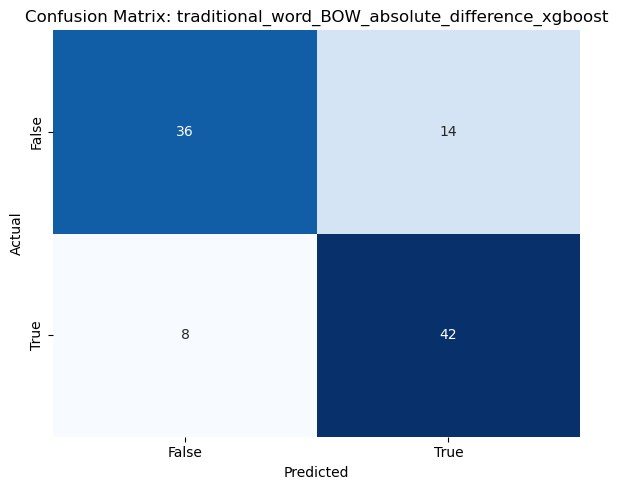

In [185]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [186]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("max_df", top_max_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("binary", top_binary)
                    
    mlflow.log_param("eta", top_eta)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("subsample", top_subsample)
    mlflow.log_param("colsample_bytree", top_colsample_bytree)
    mlflow.log_param("reg_lambda", top_reg_lambda)
    mlflow.log_param("reg_alpha", top_reg_alpha)
    mlflow.log_param("objective", top_objective)
    mlflow.log_param("eval_metric", top_eval_metric)
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("tree_method", top_tree_method)
    mlflow.log_param("use_label_encoder", top_use_label_encoder)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_BOW_absolute_difference_xgboost at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/de0c2f034ebe402fa35eab548152f9a9
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
